Epoch 1 | D Loss: 0.12027186900377274 | G Loss: 2.7325241565704346
Epoch 2 | D Loss: 0.343545138835907 | G Loss: 1.4574006795883179
Epoch 3 | D Loss: 0.11540275812149048 | G Loss: 2.9001855850219727


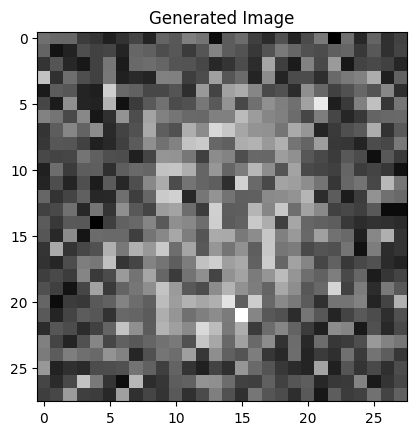

In [ ]:
# Import required libraries
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt


# STEP 1: Load and preprocess CSV
df = pd.read_csv("mnist_test.csv")

# Separate input (pixels) and normalize values
# Pixel values are 0–255 → convert to 0–1 → then scale to [-1,1] (important for GAN)
X = df.drop("label", axis=1).values / 255.0
X = (X - 0.5) / 0.5

# Convert data into PyTorch tensor
X = torch.tensor(X, dtype=torch.float32)


# STEP 2: Define Generator
# Generator takes random noise (size 100) and generates fake image (size 784)
G = nn.Sequential(
    nn.Linear(100, 128),   # input noise → hidden layer
    nn.ReLU(),             # activation
    nn.Linear(128, 784),   # hidden → output image (28x28 = 784)
    nn.Tanh()              # output range [-1,1]
)


# STEP 3: Define Discriminator
# Discriminator takes image (784) and outputs probability (real or fake)
D = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid()           # output between 0 and 1
)


# STEP 4: Loss function & optimizers
loss_fn = nn.BCELoss()  # Binary Cross Entropy (for real/fake classification)

# Optimizers for both networks
g_opt = torch.optim.Adam(G.parameters(), lr=0.001)
d_opt = torch.optim.Adam(D.parameters(), lr=0.001)



# STEP 5: Training Loop

for epoch in range(3):   # small epochs (enough for lab demo)
    for i in range(0, len(X), 64):   # batch size = 64
        real = X[i:i+64]   # real images from dataset

        # Labels: real = 1, fake = 0
        real_label = torch.ones(real.size(0), 1)
        fake_label = torch.zeros(real.size(0), 1)


        # Train Discriminator

        # 1. Train on real images
        real_output = D(real)
        d_loss_real = loss_fn(real_output, real_label)

        # 2. Train on fake images generated by Generator
        noise = torch.randn(real.size(0), 100)  # random noise input
        fake = G(noise)                         # generate fake images

        fake_output = D(fake.detach())          # detach → don't update G here
        d_loss_fake = loss_fn(fake_output, fake_label)

        # Total discriminator loss
        d_loss = d_loss_real + d_loss_fake

        # Backpropagation
        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()


        # Train Generator

        # Generator tries to fool discriminator → wants output = 1
        noise = torch.randn(real.size(0), 100)
        fake = G(noise)
        output = D(fake)

        g_loss = loss_fn(output, real_label)  # trick: use real_label

       # Updates Discriminator weights

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

    # Print loss after each epoch
    print(f"Epoch {epoch+1} | D Loss: {d_loss.item()} | G Loss: {g_loss.item()}")



# STEP 6: Generate a sample image

noise = torch.randn(1, 100)
img = G(noise).detach().view(28, 28)

# Display generated image
plt.imshow(img, cmap="gray")
plt.title("Generated Image")
plt.show()